In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
columns = ['sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']
file_data = pd.read_csv('data.csv', header=None, names=columns)

In [3]:
counts = file_data['sex'].value_counts(normalize=True) * 100
data = {
    'category': ['Male', 'Infant', 'Female'],
    'count': file_data['sex'].value_counts(),
    '%': round(counts, 2)
}

df = pd.DataFrame(data)
df.set_index('category', inplace=True)
df.index.name = None
display(df)


,count,%
Male,1528,36.58
Infant,1342,32.13
Female,1307,31.29


In [4]:
stats = {}
for column in file_data.columns[1:]:
    stats[column] = {
        'mean': file_data[column].mean(),
        'std': file_data[column].std(),
        'min': file_data[column].min(),
        '25%': file_data[column].quantile(0.25),
        '50%': file_data[column].quantile(0.5),
        '75%': file_data[column].quantile(0.75),
        'max': file_data[column].max(),
    }

df = pd.DataFrame(stats)
# df.index.name = None
df = df.T
display(df)


,mean,std,min,25%,50%,75%,max
Length,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole weight,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked weight,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera weight,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell weight,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


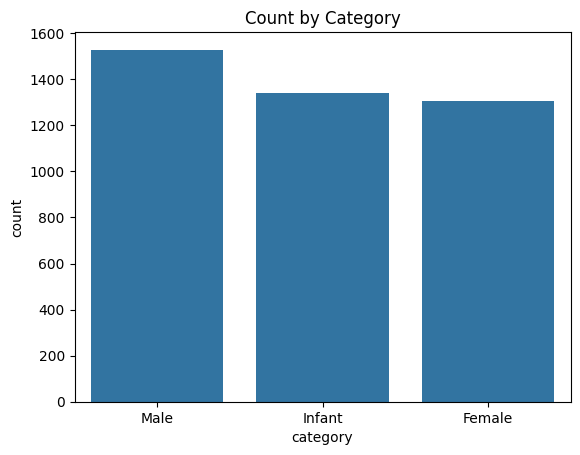

<Figure size 640x480 with 0 Axes>

In [5]:
sns.barplot(x='category', y='count', data=data)
plt.title('Count by Category')
display(plt.gcf())
plt.clf()


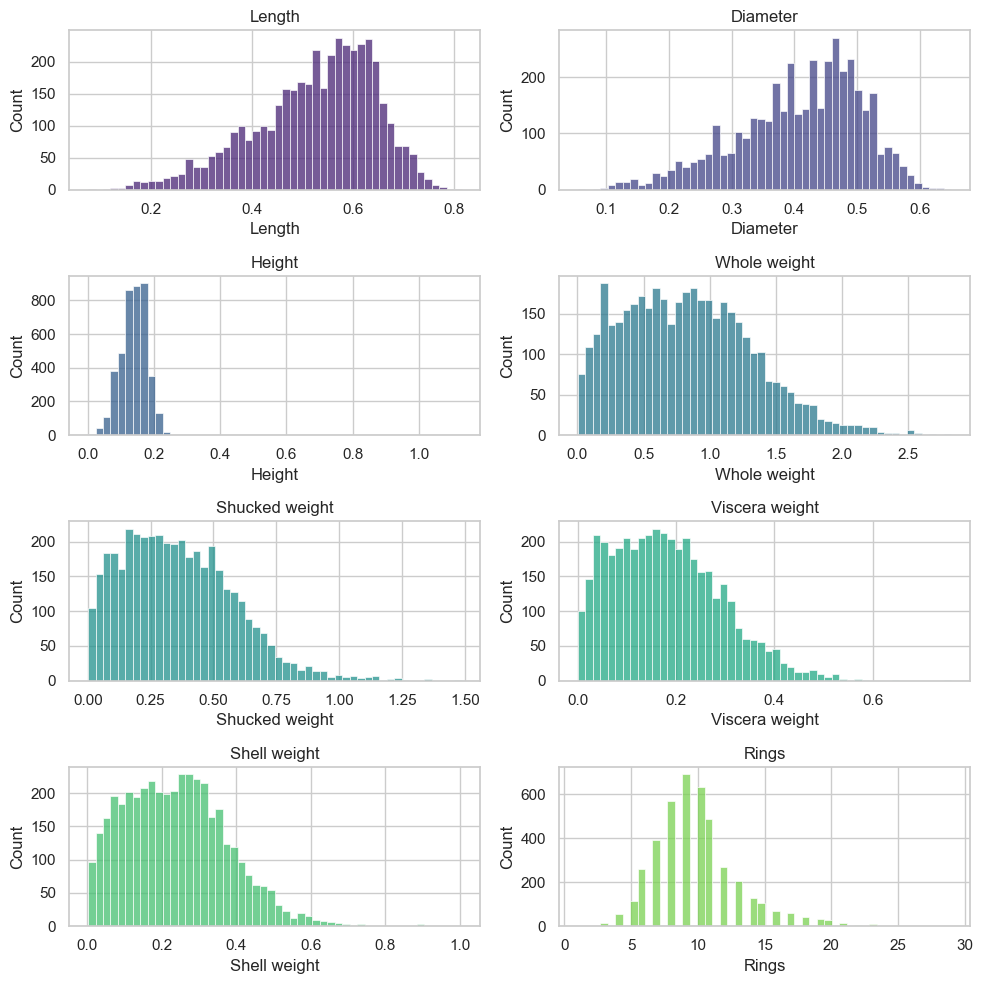

<Figure size 1000x1000 with 0 Axes>

In [6]:
sns.set(style='whitegrid')

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 10))
axes = axes.flatten()
palette = sns.color_palette("viridis", len(file_data.columns))

for i, column in enumerate(file_data.columns[1:]):
    sns.histplot(file_data[column], bins=50, color=palette[i], ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
display(fig)
plt.clf()


In [7]:
fig, axes = plt.subplots(nrows=14, ncols=2, figsize=(100, 100))
axes = axes.flatten()
count = 0

for i, column_i in enumerate(file_data.columns[1:]):
    for j, column_j in enumerate(file_data.columns[2 + i:], start=i + 1):
        sns.scatterplot(x=file_data[column_i], y=file_data[column_j], hue=file_data[column_i], ax=axes[count])
        axes[count].set_title(f'{column_i} vs {column_j}')
        count += 1

plt.subplots_adjust(hspace=0.4, wspace=0.4)
display(fig)
plt.clf()


<Figure size 10000x10000 with 0 Axes>

In [8]:
df_corr = pd.DataFrame(file_data.iloc[:, 1:]).corr()
display(df_corr)


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


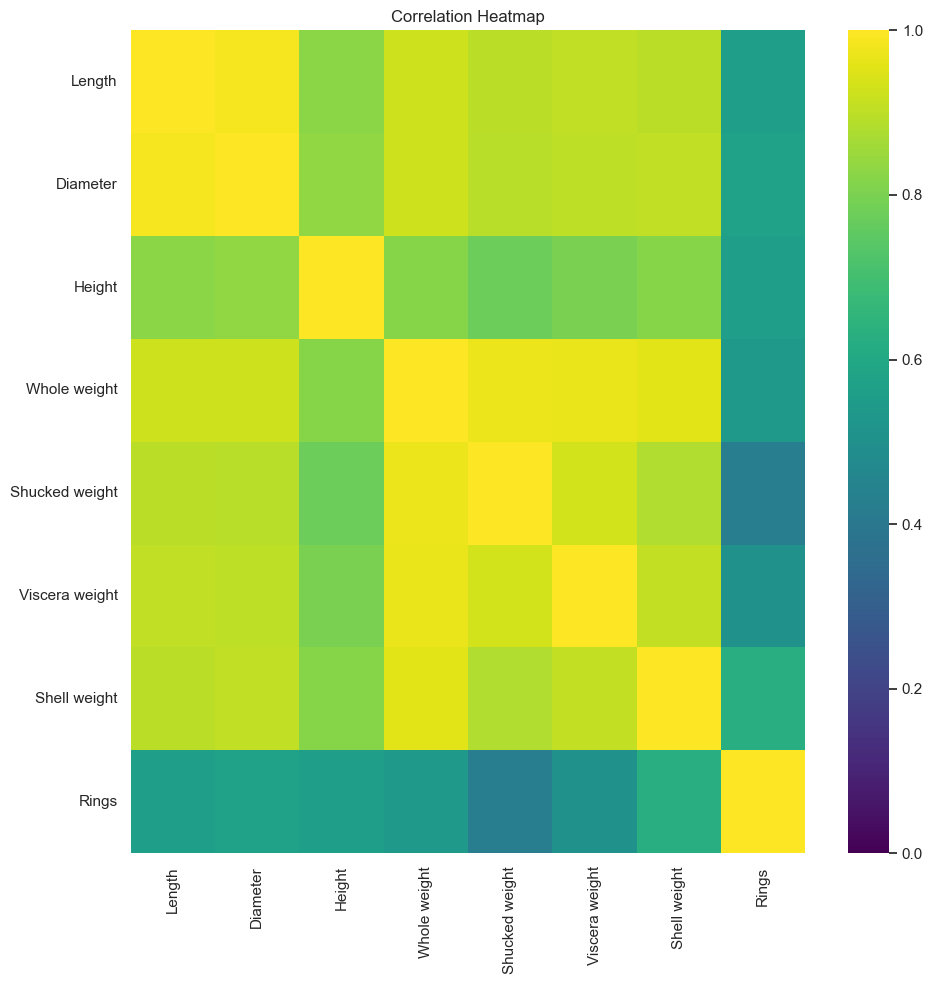

<Figure size 1000x1000 with 0 Axes>

In [9]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_corr, cmap='viridis', vmin=0, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
display(plt.gcf())
plt.clf()


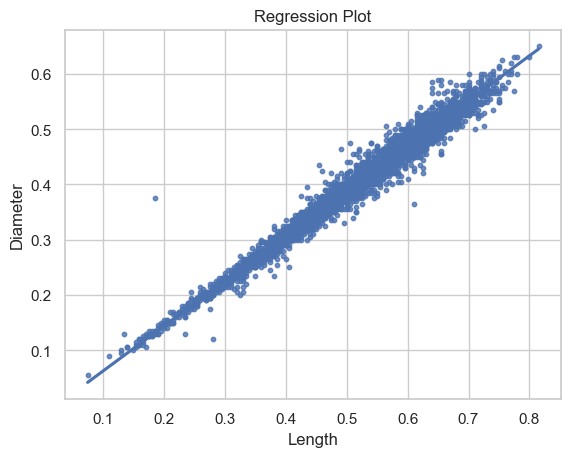

<Figure size 640x480 with 0 Axes>

In [16]:
sns.regplot(x='Length', y='Diameter', data=file_data, scatter_kws={'s': 10}, ci=None)
plt.title('Regression Plot')
display(plt.gcf())
plt.clf()


In [14]:
summary_stats = []

for col in file_data.columns[1:]:
    stats = file_data.groupby('sex')[col].agg(
        mean='mean',
        std='std',
        min='min',
        q1=lambda x: x.quantile(0.25),
        q2='median',
        q3=lambda x: x.quantile(0.75),
        max='max'
    ).reset_index()

    for _, row in stats.iterrows():
        summary_stats.append({
            'Feature': col,
            'Sex': row['sex'],
            'mean': row['mean'],
            'std': row['std'],
            'min': row['min'],
            '25%': row['q1'],
            '50%': row['q2'],
            '75%': row['q3'],
            'max': row['max']
        })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.set_index(['Feature', 'Sex'])
display(summary_df)


mean       std     min       25%       50%  \
Feature        Sex                                                    
Length         F     0.579093  0.086160  0.2750  0.525000   0.59000   
               I     0.427746  0.108858  0.0750  0.360000   0.43500   
               M     0.561391  0.102697  0.1550  0.505000   0.58000   
Diameter       F     0.454732  0.070954  0.1950  0.410000   0.46500   
               I     0.326494  0.088109  0.0550  0.270000   0.33500   
               M     0.439287  0.084398  0.1100  0.395000   0.45500   
Height         F     0.158011  0.039984  0.0150  0.140000   0.16000   
               I     0.107996  0.031995  0.0000  0.085000   0.11000   
               M     0.151381  0.034804  0.0250  0.130000   0.15500   
Whole weight   F     1.046532  0.430316  0.0800  0.730000   1.03850   
               I     0.431363  0.286275  0.0020  0.205500   0.38400   
               M     0.991459  0.470581  0.0155  0.671625   0.97575   
Shucked weight F     0.446188  0.198663  0.0310  0.295000   0.44050   
               I     0.191035  0.128405  0.0010  0.090000   0.16975   
               M     0.432946  0.223000  0.0065  0.276375   0.42175   
Viscera weight F     0.230689  0.097617  0.0210  0.159000   0.22400   
               I     0.092010  0.062536  0.0005  0.042500   0.08050   
               M     0.215545  0.104919  0.0030  0.145875   0.21000   
Shell weight   F     0.302010  0.125649  0.0250  0.213250   0.29500   
               I     0.128182  0.084927  0.0015  0.064125   0.11300   
               M     0.281969  0.130834  0.0050  0.190000   0.27600   
Rings          F    11.129304  3.104256  5.0000  9.000000  10.00000   
               I     7.890462  2.511554  1.0000  6.000000   8.00000   
               M    10.705497  3.026349  3.0000  9.000000  10.00000   

                          75%      max  
Feature        Sex                      
Length         F     0.640000   0.8150  
               I     0.510000   0.7250  
               M     0.630000   0.7800  
Diameter       F     0.505000   0.6500  
               I     0.390000   0.5500  
               M     0.500000   0.6300  
Height         F     0.175000   1.1300  
               I     0.130000   0.2200  
               M     0.175000   0.5150  
Whole weight   F     1.320250   2.6570  
               I     0.599375   2.0495  
               M     1.265625   2.8255  
Shucked weight F     0.573250   1.4880  
               I     0.270375   0.7735  
               M     0.566000   1.3510  
Viscera weight F     0.297250   0.5900  
               I     0.130000   0.4405  
               M     0.278000   0.7600  
Shell weight   F     0.375000   1.0050  
               I     0.178500   0.6550  
               M     0.355500   0.8970  
Rings          F    12.000000  29.0000  
               I     9.000000  21.0000  
               M    12.000000  27.0000

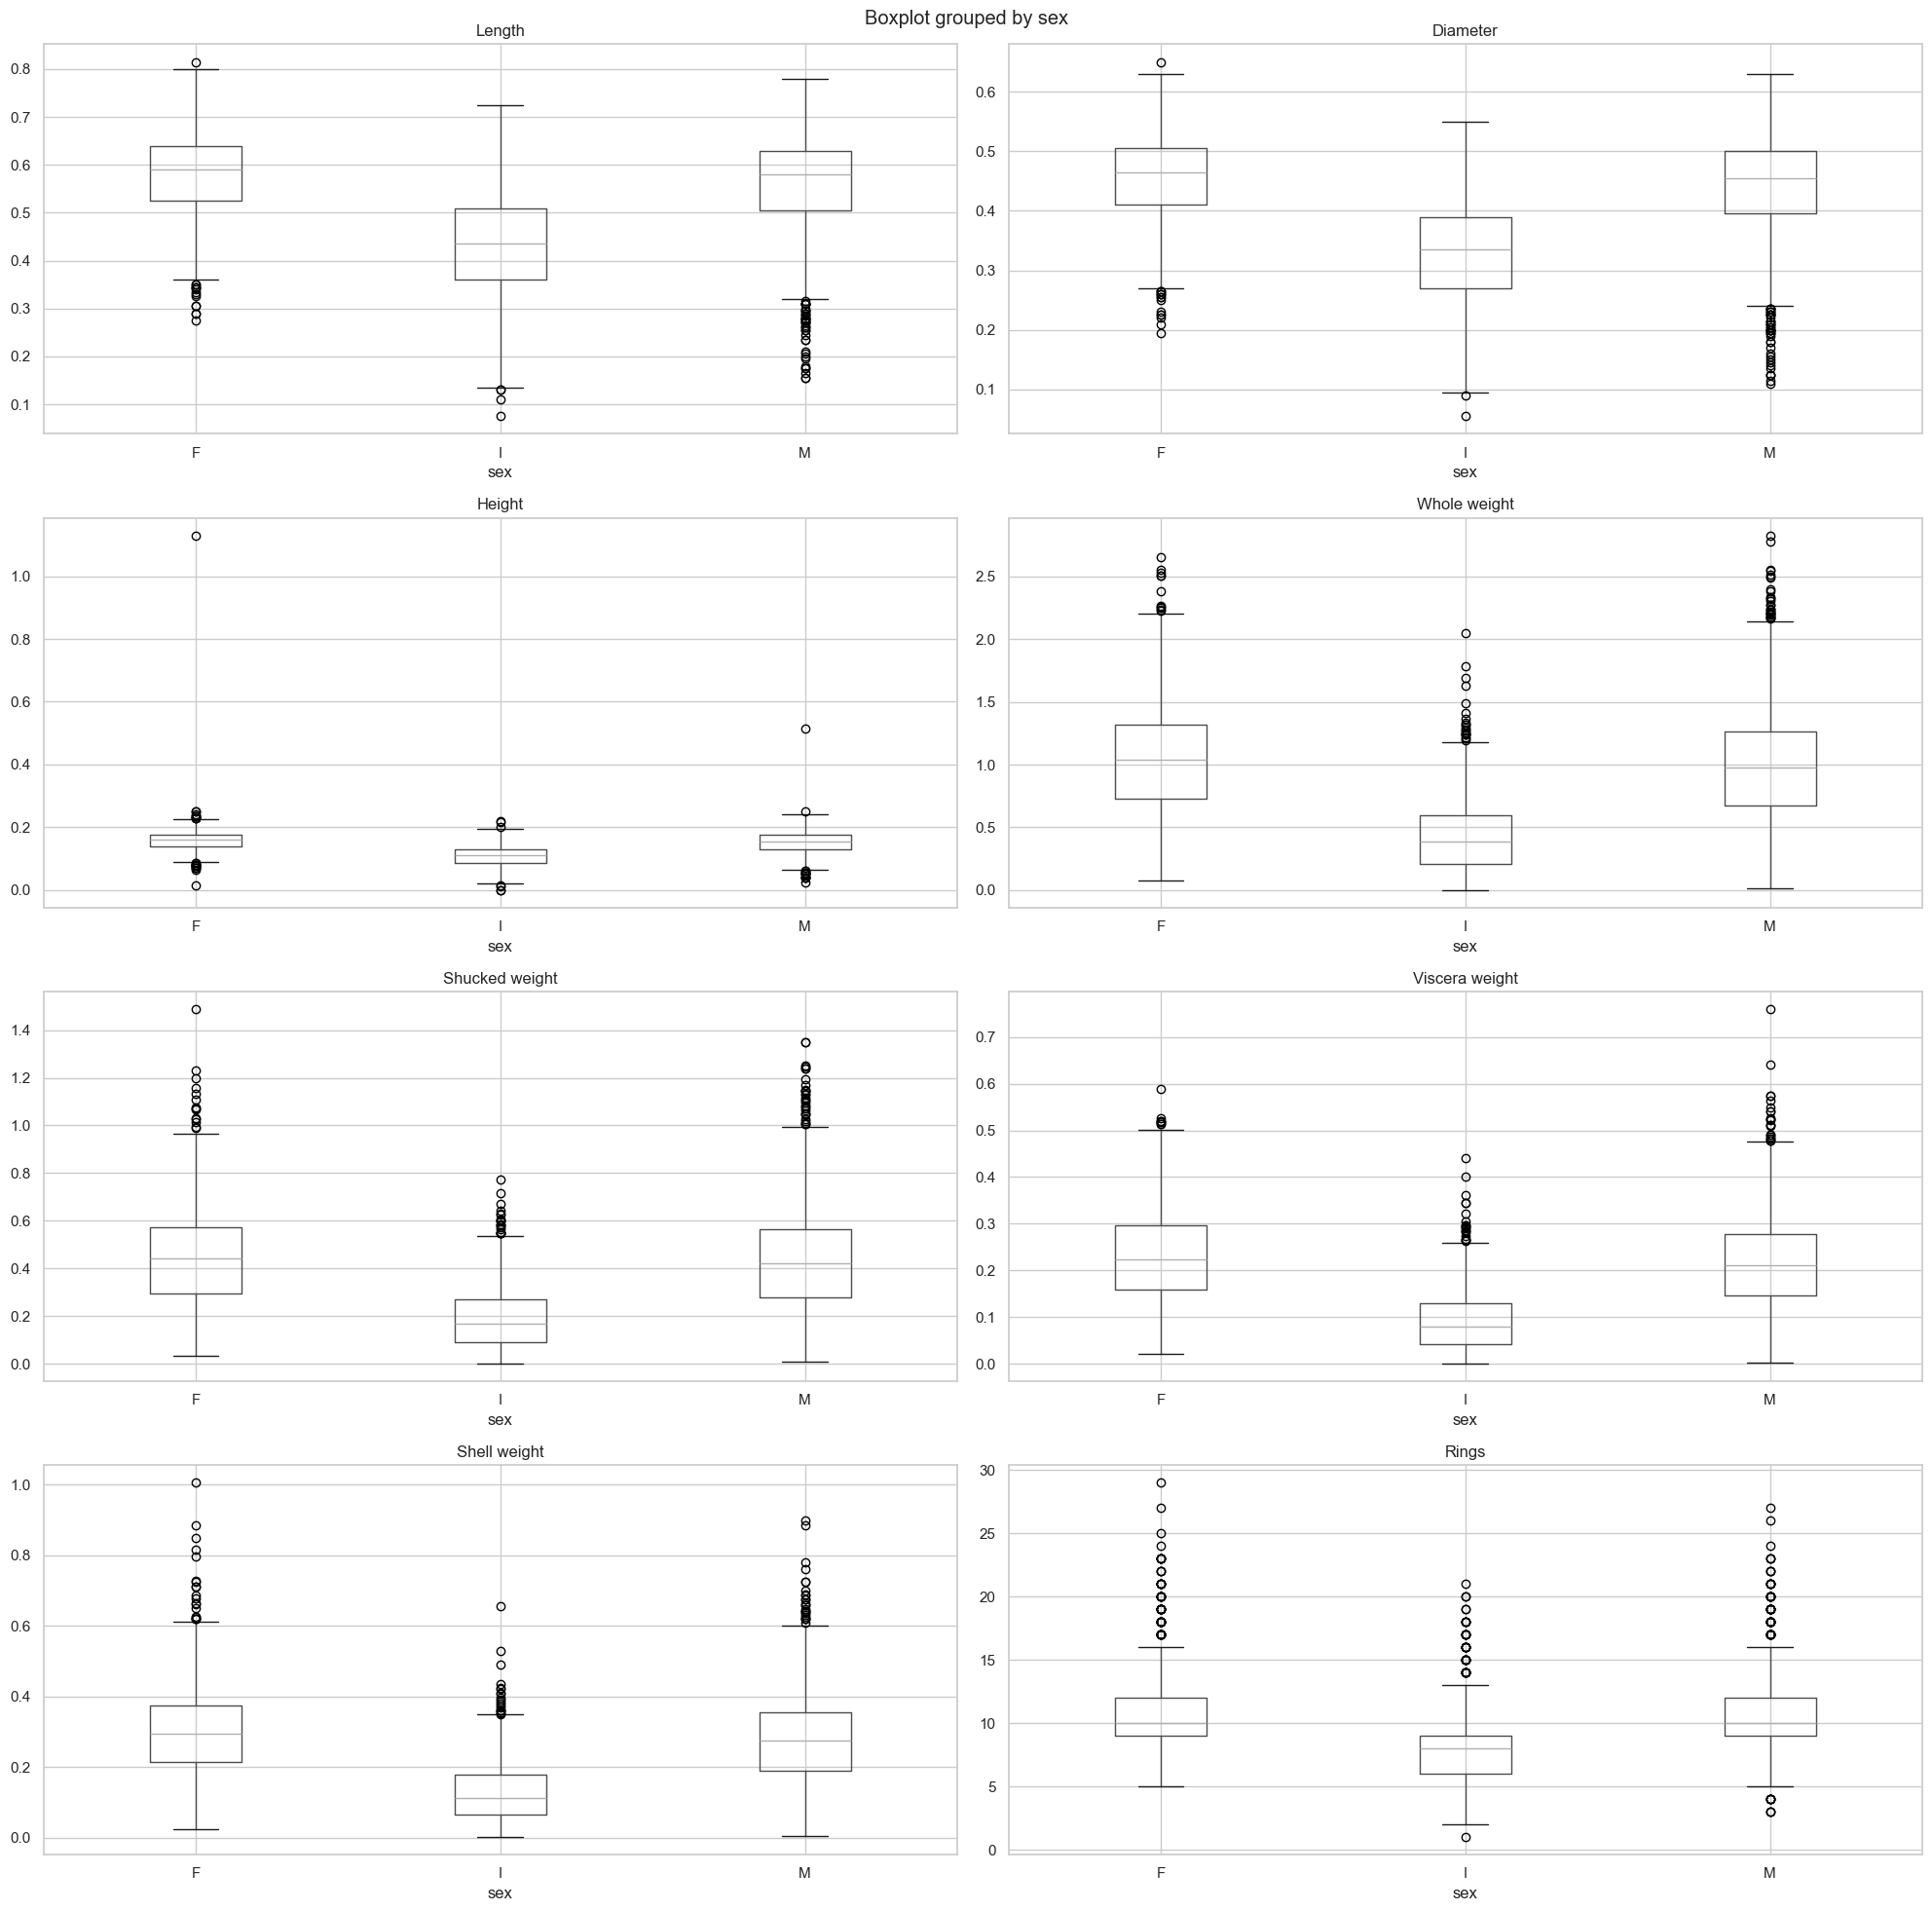

<Figure size 2000x2000 with 0 Axes>

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, name in enumerate(file_data.columns[1:]):
    bplot = file_data.boxplot(column=name, by='sex', ax=axes[i])
    bplot.set_title(name)

plt.tight_layout()
display(fig)
plt.clf()
